## Gradient descent

Đây là một phương pháp để tìm cực tiểu địa phương.


### Bài toán tìm cực trị
Chắc hẳn chúng ta đã quá quen với bài toán tìm điểm cực trị của hàm số $f(x)$. Về ý tưởng chính, chúng ta sẽ đi giải phương trình:
$$
f'(x) = 0 \space (*)
$$
Tuy nhiên, sẽ có những phương trình $(*)$ chúng ta không thể giải được vì quá khó hoặc quá phức tạp, vậy có cách nào khác để tính không? Câu trả lời là có, **Gradient descent** là một phương pháp - sẽ được trình bày bên dưới.

#### Nhắc lại về cách tính đạo hàm

Thông thường, khi đạo hàm, ta sẽ áp dụng các công thức đạo hàm của một số hàm sơ cấp, quy tắc đạo hàm tích, quy tắc chuỗi, ... Tuy nhiên, có một công thức tính đạo hàm tổng quát của hàm bất kỳ được tính như sau:
$$
f'(x) = \lim_{\Delta x \to 0}\frac{f(x + \Delta x) - f(x)}{\Delta x}
$$

#### Công thức tính gần đúng đạo hàm một biến

##### Ký hiệu chung
- $y_k = f(x_k)$
- $x_{k + i} = x_k + i\cdot \Delta x$

##### Công thức 2 điểm
$$
f'(x_k) = \frac{y_{k+1} - y_k}{\Delta x}
$$

##### Công thức 3 điểm

Công thức cận trái:
$$
f'(x_k) = \frac{-y_{k+2} +4y_{k+1} - 3y_k}{2\Delta x}
$$

Công thức trung tâm:
$$
f'(x_k) = \frac{y_{k+1} - y_{k-1}}{2\Delta x}
$$

Công thức cận phải:
$$
f'(x_k) = \frac{y_{k-2} - 4y_{k-1} + 3y_k}{2\Delta x}
$$


#### Đạo hàm của hàm nhiều biến
Hàm nhiều biến $f(\mathbf{x})$, với $\mathbf{x} = (x_1, x_2, ..., x_n)$

$$
f'(\mathbf{x}) = \nabla _\mathbf{x} f(\mathbf{x}) = \left(\frac{\partial f}{\partial x_1}, ..., \frac{\partial f}{\partial x_n}\right)
$$

#### Gradient descent
**B1**. Khởi tạo $\mathbf{x}_0$ ngẫu nhiên, $t = 0$  
**B2**. Cập nhật $x_{t+1} = \mathbf{x}_t - \eta f'(\mathbf{x}_{t - 1})$  
**B3**. Cập nhật $t = t + 1$  
**B4**. Nếu đạt điều kiện dừng thì kết thúc, không thì quay lại **B2**

Trong thuật toán trên, $\eta$ được gọi là ***learning rate***

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def partial(func, x, d = 1e-6):
    y_0 = func(x - 2*d)
    y_1 = func(x - d)
    y_2 = func(x)
    y_3 = func(x + d)
    y_4 = func(x + 2*d)
    y_L = (-y_4 + 4*y_3 - 3*y_2)/(2*d)
    y_M = (y_3 - y_1)/(2*d)
    y_R = ( y_0 - 4*y_1 + 3*y_2)/(2*d)
    return (y_L + y_M + y_R) / 3   

def derivative(func, x, d = 1e-6):
    if np.isscalar(x):
        return partial(func, x)
    else:
        return np.array([partial(func, xi) for xi in x])

In [2]:
def GD(func, x0, eta = 0.02, epsilon = 1e-3):
    x = [x0]
    v = [0]
    for it in range(100):
        grad = derivative(func, x[-1])
        v.append(- eta * grad)
        x.append(x[-1] + v[-1])
        if np.linalg.norm(derivative(func, x[-1])) < epsilon:
            break
    return x, it

In [3]:
def draw(func, x_points, start=-10, end=10, num_point=400, show_point = False):
    # Vẽ hàm số
    x = np.linspace(start, end, num_point)
    y = func(x)
    plt.plot(x, y, label='f(x)', color='blue')

    if show_point:
        y_points = [func(xi) for xi in x_points]
        plt.scatter(x_points, y_points, color='red', label='Point', zorder=5)

    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.legend()
    plt.grid(True)

In [4]:
def func(x):
    # return x**2 + 5*np.sin(x)
    return 2 * x**4 - 3 * x**3 + x


Iteration : 18
Best Point: 1.0001267116008967
Best Value: 4.8177661859938326e-08


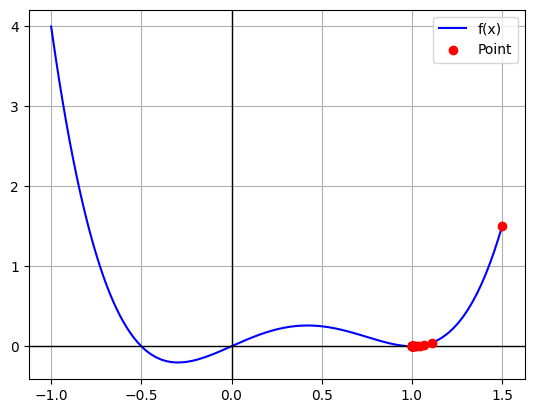

In [5]:

x, it = GD(func, x0 = 1.5, eta = 0.05)
print(f"Iteration : {it}")
print(f"Best Point: {x[-1]}")
print(f"Best Value: {func(x[-1])}")
draw(func, x, -1, 1.5, show_point=True)

## Gradient Descent Momentum

Nhắc lại về công thức cập nhật điểm trong **Gradient Descent**
$$
\mathbf{x}_t = \mathbf{x}_{t-1} - \eta f'(\mathbf{x}_{t - 1}) 
$$

Nếu điểm hiện tại là $\mathbf{x}_{t-1}$, điểm tiếp theo là $\mathbf{x}_t$, thì biểu thị sự di chuyển từ điểm này tới điểm kia là vận tốc $\mathbf{v}_{t-1} = -\eta f'(\mathbf{x}_{t - 1})$, khi đó công thức được viết lại
$$
\mathbf{x}_t = \mathbf{x}_{t-1} + \mathbf{v}_{t-1}
$$
Tuy nhiên, khi đạt cực trị, $\mathbf{v}_{t-1} = 0$ tức không có sự di chuyển nào! Điều này sẽ dẫn đến điểm sẽ bị mắc kẹt tại cực trị địa phương. Một trong những giải pháp được hy vọng là giúp thoát ra khỏi cực trị địa phương đó là **Gradient Descent Momentum**, về ý tưởng vận tốc sẽ được bổ sung thêm thông tin về quán tính. Một trong những cách đơn giản nhất là xem xét vận tốc trước đó
$$
\mathbf{v}_t = -\eta f'(\mathbf{x}_{t - 1}) + \gamma \mathbf{v}_{t - 1}
$$

In [6]:
def GDM(func, x0, eta = 0.02, gamma = 0.001, epsilon = 1e-3):
    x = [x0]
    v = [0]
    for it in range(100):
        grad = derivative(func, x[-1])
        v.append(gamma * v[-1] - eta * grad)
        x.append(x[-1] + v[-1])
        if np.linalg.norm(derivative(func, x[-1])) < epsilon:
            break
    return x, it

Iteration : 36
Best Point: -0.29640375515874845
Best Value: -0.20284486653326567


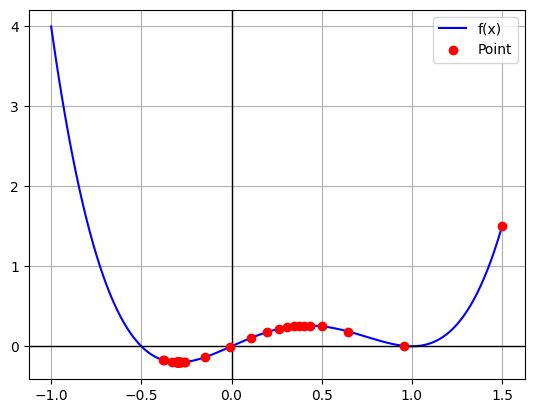

In [7]:
x, it = GDM(func, x0 = 1.5, eta = 0.07, gamma=0.6)
print(f"Iteration : {it}")
print(f"Best Point: {x[-1]}")
print(f"Best Value: {func(x[-1])}")
draw(func, x, -1, 1.5, show_point=True)

## Nesterov Accelerated Gradient
Momentum được thiết kế với hy vọng thoát ra khỏi điểm cực tiểu cục bộ, nhưng tuy nhiên, tốc độ hội tụ chậm do quán tính, để khắc phục điều đó NAG được thiết kế để tăng tốc độ hội tụ của GDM. Về ý tưởng, thay vì đi tìm đạo hàm tại điểm hiện tại, NAG sẽ đi tìm đạo hàm tại điểm tiếp theo
$$
\mathbf{v}_t 
= \gamma\mathbf{v}_{t - 1} - \eta f'(\mathbf{x}_{t}) 
= \gamma\mathbf{v}_{t - 1} - \eta f'(\mathbf{x}_{t - 1} + \mathbf{v}_{t - 1})
$$

In [8]:
def NCA(func, x0, eta = 0.02, gamma = 0.001, epsilon = 1e-3):
    x = [x0]
    v = [0]
    for it in range(100):
        grad = derivative(func, x[-1] + v[-1])
        v.append(gamma * v[-1] - eta * grad)
        x.append(x[-1] + v[-1])
        if np.linalg.norm(derivative(func, x[-1])) < epsilon:
            break
    return x, it

Iteration : 12
Best Point: -0.2964241702208959
Best Value: -0.20284488495753009


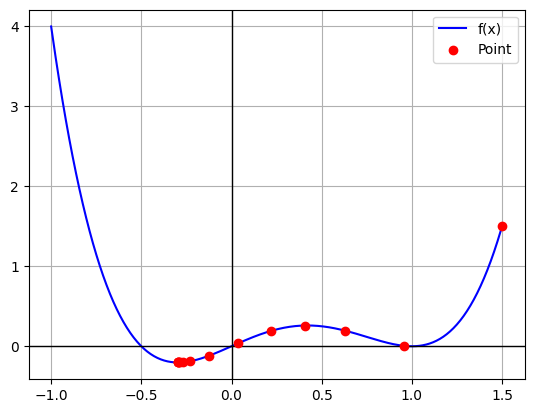

In [9]:
x, it = NCA(func, x0 = 1.5, eta = 0.07, gamma=0.6)
print(f"Iteration : {it}")
print(f"Best Point: {x[-1]}")
print(f"Best Value: {func(x[-1])}")
draw(func, x, -1, 1.5, show_point=True)

## Công thức khác đề xuất

Công thức này sẽ gần đúng với thế giới vật lý tự nhiên, khi thả một viên vi trên một con dốc, tốc độ của viên bi sẽ tăng, sự tăng này nhờ vào gia tốc trọng trường $g$ của Trái Đất. Tuy nhiên, phần gia tốc có ý nghĩa là phần gia tốc chiếu theo phương của vận tốc.

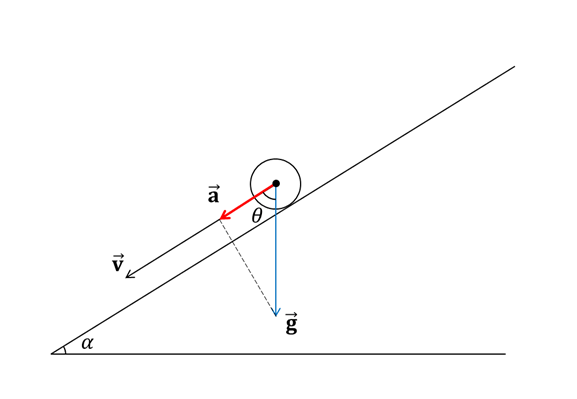

$$
\mathbf{v}_t = \mathbf{v}_{t - 1} + \Delta t\cdot\mathbf{a}_{t - 1}
$$

Với:
$$
\mathbf{a}_{t} = \mathbf{g}\cdot\cos{\theta} = \mathbf{g}\cdot\sin{\alpha} = \mathbf{g}\cdot\sin{(\arctan{f'(\mathbf{x}_{t})})}
$$

In [10]:
def GDG(func, x0, g = 9.8, eta = 0.2, d = 0.01, epsilon = 1e-3):
    x = [x0]
    v = [0]
    for it in range(100):
        grad = derivative(func, x[-1])
        a = -g*np.sin(np.arctan(grad))
        v.append(v[-1] + d*a)
        grad = grad / np.linalg.norm(grad) * v[-1]
        x.append(x[-1] + eta * grad)
        # print(f"x = {x[-1]}\nv = {v[-1]}\n====")
        if np.linalg.norm(derivative(func, x[-1])) < epsilon:
            break
    return x, it

Iteration : 99
Best Point: -0.5132395944142327
Best Value: 0.031120045423442044


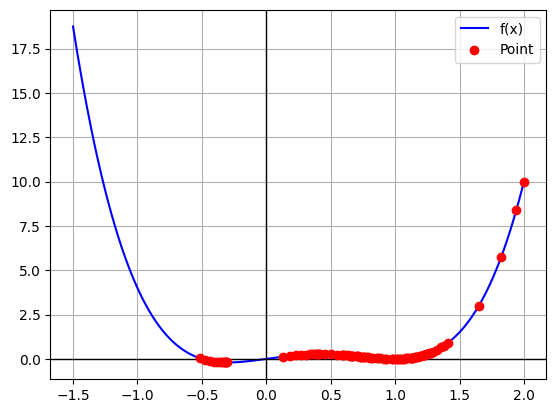

In [11]:
x, it = GDG(func, x0 = 2, d = 0.03)
print(f"Iteration : {it}")
print(f"Best Point: {x[-1]}")
print(f"Best Value: {func(x[-1])}")
draw(func, x, -1.5, 2, show_point=True)

### Stochastic Gradient Descent (SGD)

Mục đích của Note này là trình bày các phương pháp tìm cực tiểu của hàm số, cụ thể là hàm mất mát

$$
\mathcal{L}(\mathbf{w}) = \sum_{i = 1}^N{\mathcal{L}(\hat{y}_i, y_i)}
$$

Tính gradient trên toàn bộ tập dữ liệu:
$$
\nabla _\mathbf{w}\mathcal{L}(\mathbf{w}) = \frac{1}{N} \sum_{i = 1}^N{\nabla _\mathbf{w}\mathcal{L}(\hat{y}_i, y_i)}
$$
Sau đó, ta cập nhật tất cả các trọng số $\mathbf{w}$
$$
\mathbf{w}_{t + 1} = \mathbf{w}_t - \eta \nabla _\mathbf{w}\mathcal{L}(\mathbf{w}_t) 
$$
Đây là cách tính Gradient Descent truyền thống, đó là tính trên toàn bộ tập dữ liệu. Với bộ dữ liệu lớn, hoặc bộ dữ liệu luôn được cập nhật liên tục (online learning) thì cách tính toán này rất tốn chi phí. 

SGD được đề xuất để khắc phục điều trên, về ý tưởng SGD tính đạo hàm trên từng điểm dữ liệu $\mathbf{x}_i$ và tiếp hành cập nhật $\mathbf{w}$
Chọn ra một điểm dữ liệu $\mathbf{x}_i$ ngẫu nhiên và tính đạo hàm tại điểm dữ liệu đó
$$
\nabla _\mathbf{w}\mathcal{L}(\mathbf{w}) = \nabla _\mathbf{w}\mathcal{L}(\hat{y}_i, y_i)$$

## Mini-batch gradient descent
Về ý tưởng MGD giống với SGD, tuy nhiên thay vì cập nhật trên một điểm dữ liệu, MGD chọn ra $k$ điểm dữ liệu ngẫu nhiên và cập nhật trên $k$ điểm

$$
\nabla _\mathbf{w}\mathcal{L}(\mathbf{w}) = \frac{1}{k} \sum_{i = 1}^k{\nabla _\mathbf{w}\mathcal{L}(\hat{y}_i, y_i)}
$$

